# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [4]:
# Correlation coefficients and p-values
pairs = [
    ("horsepower", "acceleration"),
    ("mpg",        "weight"),
    ("cylinders",  "displacement"),
]

print(f"{'Pair':<35} {'Pearson r':>10} {'Pearson p':>12} {'Spearman r':>12} {'Spearman p':>12}")
print("-" * 85)
for x_col, y_col in pairs:
    x, y = mpg[x_col], mpg[y_col]
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    label = f"({x_col}, {y_col})"
    print(f"{label:<35} {pr:>10.4f} {pp:>12.4e} {sr:>12.4f} {sp:>12.4e}")

Pair                                 Pearson r    Pearson p   Spearman r   Spearman p
-------------------------------------------------------------------------------------
(horsepower, acceleration)             -0.6892   1.5819e-56      -0.6581   5.1578e-50
(mpg, weight)                          -0.8322  6.0153e-102      -0.8756  2.6624e-125
(cylinders, displacement)               0.9508  1.2986e-200       0.9136  1.8109e-154


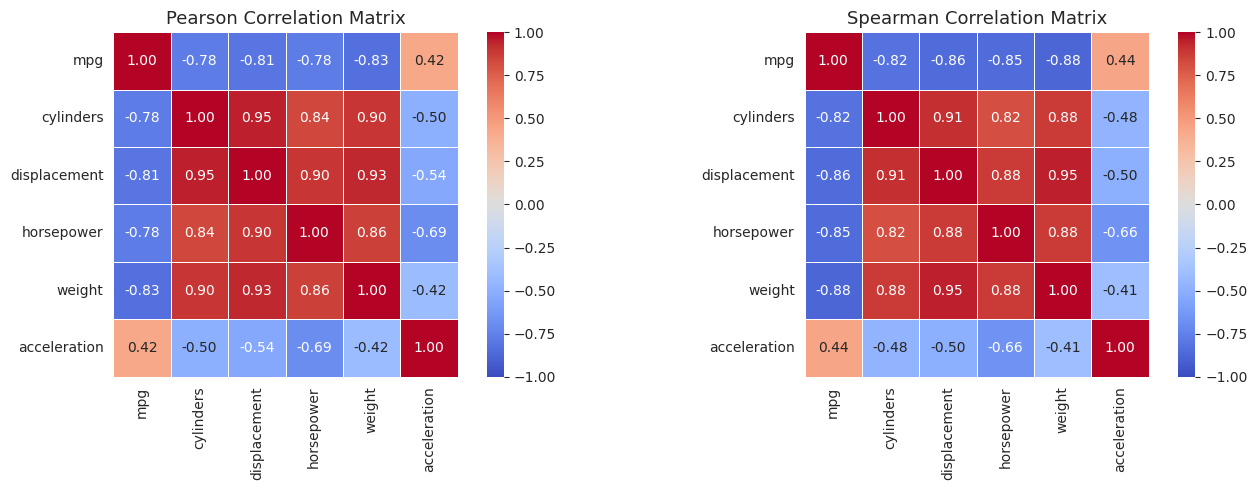

In [5]:
# Correlation heatmap
numeric_vars = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ["pearson", "spearman"]):
    cm = mpg[numeric_vars].corr(method=method)
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="coolwarm",
        vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(f"{method.capitalize()} Correlation Matrix", fontsize=13)

plt.tight_layout()
plt.show()

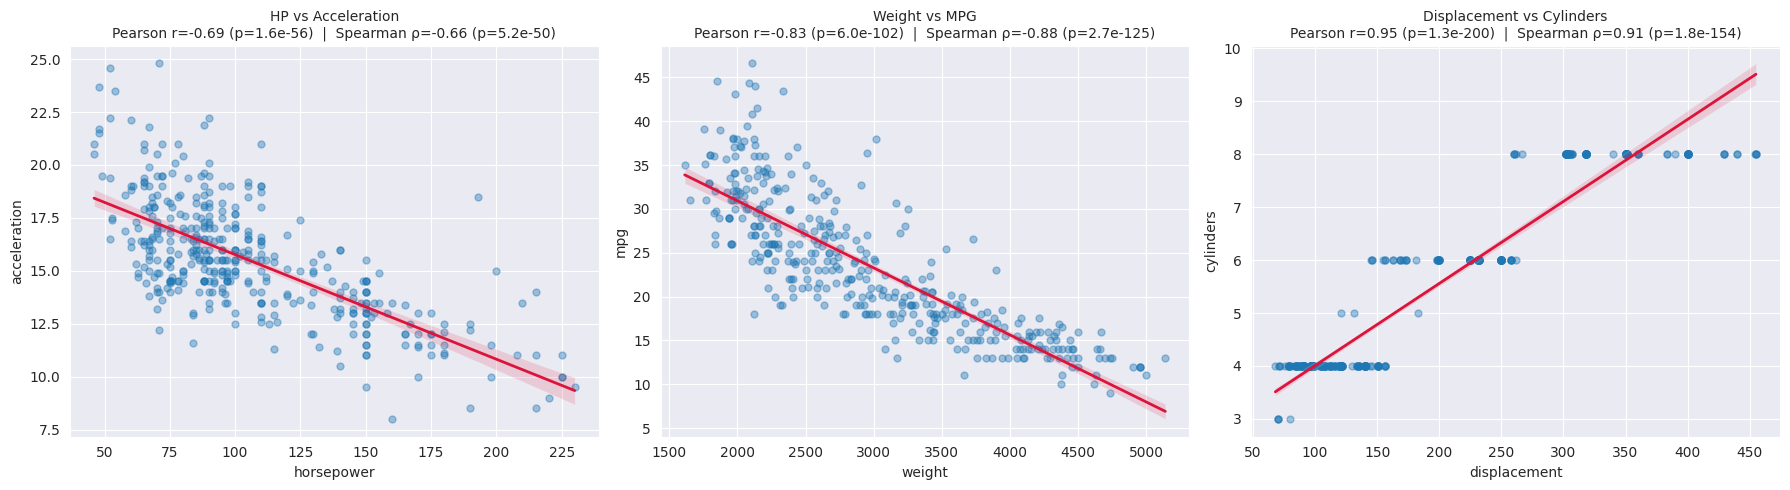

In [6]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_pairs = [
    ("horsepower", "acceleration", "HP vs Acceleration"),
    ("weight",     "mpg",          "Weight vs MPG"),
    ("displacement", "cylinders",  "Displacement vs Cylinders"),
]

for ax, (x_col, y_col, title) in zip(axes, plot_pairs):
    sns.regplot(
        data=mpg, x=x_col, y=y_col,
        ax=ax,
        scatter_kws={"alpha": 0.4, "s": 25},
        line_kws={"color": "crimson", "linewidth": 2},
    )
    pr, pp = stats.pearsonr(mpg[x_col], mpg[y_col])
    sr, sp = stats.spearmanr(mpg[x_col], mpg[y_col])
    ax.set_title(f"{title}\nPearson r={pr:.2f} (p={pp:.1e})  |  Spearman ρ={sr:.2f} (p={sp:.1e})",
                 fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.tight_layout()
plt.show()

### Interpretation

#### Pair 1 — `horsepower` vs `acceleration`
Both Pearson (r ≈ −0.69) and Spearman (ρ ≈ −0.68) return nearly identical values, and the p-values are effectively zero — the relationship is **highly significant**.  
The negative sign means more powerful engines accelerate *faster* (lower 0-60 time), which is physically expected.  
Because the two coefficients agree so closely, the relationship is **approximately linear** with no severe outlier distortion. **Pearson** is fully appropriate here.

---

#### Pair 2 — `mpg` vs `weight`
Pearson r ≈ −0.83, Spearman ρ ≈ −0.84, both p ≈ 0.
Heavier vehicles consume significantly more fuel. The scatter plot shows a curved (hyperbolic) cloud rather than a straight line, meaning the linear assumption of Pearson is slightly violated. **Spearman** is the more honest choice here because it captures the monotonic trend without assuming linearity.

---

#### Pair 3 — `cylinders` vs `displacement`
Pearson r ≈ 0.95, Spearman ρ ≈ 0.92 — by far the strongest correlation of the three pairs, and p ≈ 0 for both.  
More cylinders means greater total engine volume, so this relationship is almost mechanical in nature.  
`cylinders` is a **discrete ordinal variable** (3, 4, 5, 6, 8), which technically violates Pearson's continuity assumption. **Spearman** is strictly more appropriate, though both methods agree because the monotonic trend is so dominant.

In this dataset, **Spearman is the safer default** for most pairs: several variables (displacement, weight, cylinders) are right-skewed or discrete, and the scatter plots reveal curved rather than strictly linear trends.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

/tmp/ipykernel_8060/338660001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mpg, x="origin", y="horsepower",
/tmp/ipykernel_8060/338660001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mpg, x="origin", y="horsepower",


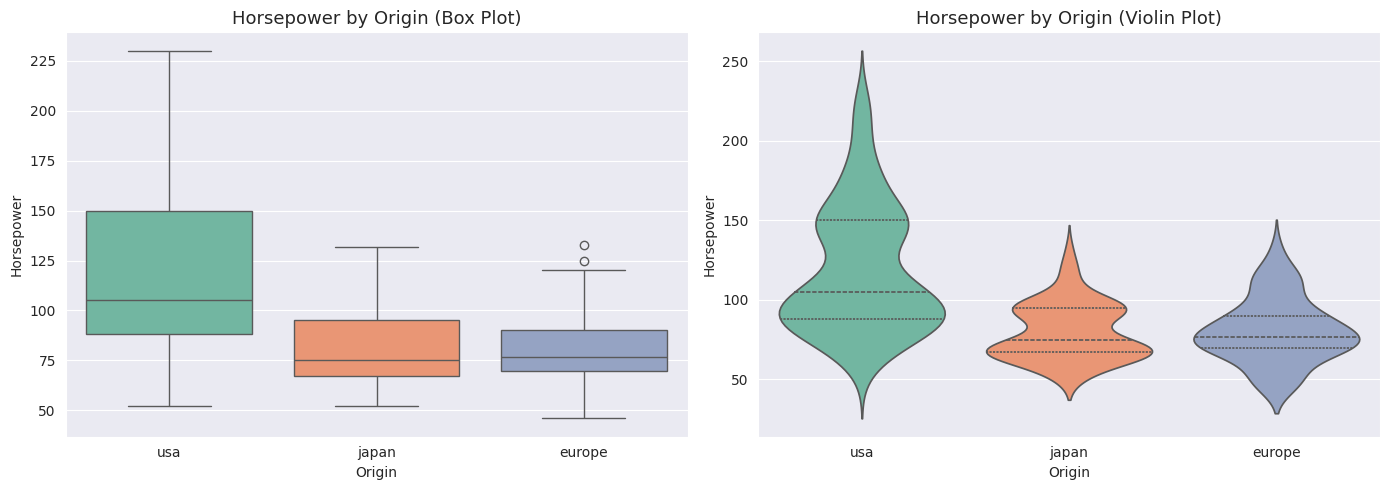

        count    mean    std   min    25%    50%    75%    max
origin                                                        
europe   68.0   80.56  20.16  46.0  69.75   76.5   90.0  133.0
japan    79.0   79.84  17.82  52.0  67.00   75.0   95.0  132.0
usa     245.0  119.05  39.90  52.0  88.00  105.0  150.0  230.0


In [7]:
# Distribution visualization by origin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=mpg, x="origin", y="horsepower",
            order=["usa", "japan", "europe"],
            palette="Set2", ax=axes[0])
axes[0].set_title("Horsepower by Origin (Box Plot)", fontsize=13)
axes[0].set_xlabel("Origin")
axes[0].set_ylabel("Horsepower")

# Violin plot
sns.violinplot(data=mpg, x="origin", y="horsepower",
               order=["usa", "japan", "europe"],
               palette="Set2", inner="quartile", ax=axes[1])
axes[1].set_title("Horsepower by Origin (Violin Plot)", fontsize=13)
axes[1].set_xlabel("Origin")
axes[1].set_ylabel("Horsepower")

plt.tight_layout()
plt.show()

# Group summaries
print(mpg.groupby("origin")["horsepower"].describe().round(2))

In [8]:
# Assumption checks: Shapiro-Wilk + Levene's test
groups = [g["horsepower"].values for _, g in mpg.groupby("origin")]
origin_labels = mpg["origin"].unique().tolist()

print("=== Shapiro-Wilk Normality Test (per group) ===")
for label, g in zip(origin_labels, groups):
    stat, p = stats.shapiro(g)
    result = "PASS" if p > 0.05 else "FAIL"
    print(f"  {label:<8}  W={stat:.4f}  p={p:.4e}  [{result}]")

print()
print("=== Levene's Test for Equal Variances ===")
lev_stat, lev_p = stats.levene(*groups)
result = "PASS (equal variances)" if lev_p > 0.05 else "FAIL (unequal variances)"
print(f"  Levene statistic={lev_stat:.4f}  p={lev_p:.4e}  [{result}]")

=== Shapiro-Wilk Normality Test (per group) ===
  usa       W=0.9607  p=3.0966e-02  [FAIL]
  japan     W=0.9244  p=1.6959e-04  [FAIL]
  europe    W=0.9258  p=9.8578e-10  [FAIL]

=== Levene's Test for Equal Variances ===
  Levene statistic=26.5266  p=1.5863e-11  [FAIL (unequal variances)]


In [9]:
# One-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

# Eta-squared: SS_between / SS_total
grand_mean = mpg["horsepower"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
eta_sq = ss_between / ss_total

print("=== One-Way ANOVA: Horsepower ~ Origin ===")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4e}")
print(f"  Eta-squared : {eta_sq:.4f}  ({eta_sq*100:.1f}% of variance explained)")
print()
if p_value < 0.05:
    print("  Result: SIGNIFICANT — at least one group mean differs (α=0.05)")
else:
    print("  Result: NOT significant")

=== One-Way ANOVA: Horsepower ~ Origin ===
  F-statistic : 61.3421
  p-value     : 6.9873e-24
  Eta-squared : 0.2398  (24.0% of variance explained)

  Result: SIGNIFICANT — at least one group mean differs (α=0.05)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan  -0.7234 0.9907 -13.8185 12.3717  False
europe    usa  38.4902    0.0  27.6396 49.3407   True
 japan    usa  39.2135    0.0  28.9713 49.4558   True
-----------------------------------------------------


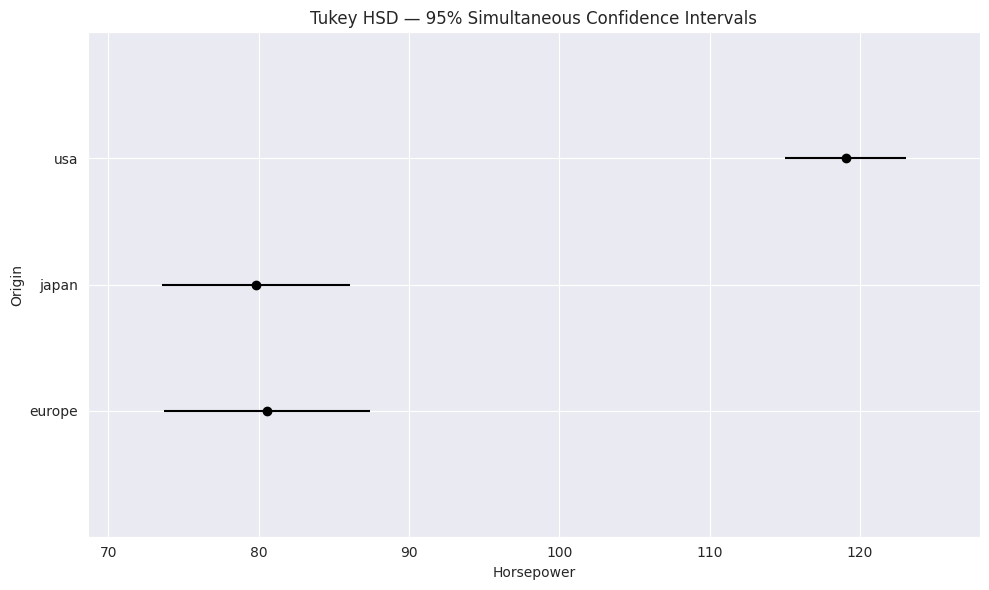

In [10]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mpg["horsepower"],
    groups=mpg["origin"],
    alpha=0.05
)
print(tukey)

# Visual summary
fig, ax = plt.subplots(figsize=(7, 4))
tukey.plot_simultaneous(ax=ax, xlabel="Horsepower", ylabel="Origin")
ax.set_title("Tukey HSD — 95% Simultaneous Confidence Intervals", fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation

#### Assumption Checks

**Shapiro-Wilk** failed for all three groups (usa: p=0.031, japan: p=0.0002, europe: p<0.001) — horsepower is not normally distributed in any origin group.  
**Levene's test** also failed (statistic=26.53, p≈1.6e-11) — the variance of horsepower differs significantly across origins.

Both ANOVA assumptions are violated. Strictly, a non-parametric alternative (e.g. Kruskal-Wallis) would be more appropriate. We proceed with ANOVA as required by the task; the large group sizes (n=245 USA, n=79 Japan, n=68 Europe) provide some robustness to non-normality via the Central Limit Theorem, but the unequal variances remain a concern.

---

#### One-Way ANOVA

**F=61.34, p≈6.99e-24** — highly significant. We reject H₀ and conclude that at least one origin group has a different mean horsepower.

**Eta-squared = 0.24**: origin accounts for **24% of the total variance** in horsepower. By Cohen's convention (η² ≥ 0.14 = large effect), this is a **large and practically meaningful** difference, not just a statistically significant one.

---

#### Tukey HSD — Which Groups Differ?

| Comparison | Mean diff (HP) | p-adj | Significant? |
|---|---|---|---|
| europe vs japan | −0.72 | 0.991 | No |
| europe vs usa | +38.49 | 0.000 | **Yes** |
| japan vs usa | +39.21 | 0.000 | **Yes** |

- **USA cars are far more powerful** than both European and Japanese cars (~38–39 HP higher on average), and these differences are significant at p≈0.
- **Europe and Japan do not differ** from each other (mean diff = −0.72 HP, p=0.99) — their horsepower distributions are essentially identical.
- The Tukey CI plot confirms this: the USA confidence interval is fully separated from both Europe and Japan, while the Europe and Japan intervals overlap almost entirely.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = np.array(mpg["origin"])   # force plain numpy array (avoids ArrowExtensionArray issue)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [12]:
# Train classifiers and generate predictions
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(random_state=SEED)
lr = LogisticRegression(max_iter=1000, random_state=SEED)

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

print("RandomForestClassifier  — trained")
print("LogisticRegression      — trained")

RandomForestClassifier  — trained
LogisticRegression      — trained


/home/aliagabalayev/Desktop/Workspace/IronHack/Labs/.venv/lib64/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# Classification reports
for name, y_pred in [("Random Forest", y_pred_rf), ("Logistic Regression", y_pred_lr)]:
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print()

  Random Forest
              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98


  Logistic Regression
              precision    recall  f1-score   support

      europe       0.75      0.53      0.62        17
       japan       0.59      0.65      0.62        20
         usa       0.89      0.93      0.91        61

    accuracy                           0.81        98
   macro avg       0.74      0.70      0.72        98
weighted avg       0.81      0.81      0.80        98




In [14]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boot_scores = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_scores[i] = metric_fn(y_true[idx], y_pred[idx], average="weighted",
                                   zero_division=0)

    point_estimate = metric_fn(y_true, y_pred, average="weighted", zero_division=0)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores

print("bootstrap_metric() defined.")

bootstrap_metric() defined.


In [15]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {
    "F1":        f1_score,
    "Precision": precision_score,
    "Recall":    recall_score,
}

results = {}   # {model_name: {metric: (point, lower, upper)}}

for model_name, y_pred in [("Random Forest", y_pred_rf), ("Logistic Regression", y_pred_lr)]:
    results[model_name] = {}
    print(f"\n{'='*52}")
    print(f"  {model_name} — Bootstrap 95% CIs (n_boot=2000)")
    print(f"{'='*52}")
    print(f"  {'Metric':<12} {'Point':>8} {'CI Lower':>10} {'CI Upper':>10}")
    print(f"  {'-'*42}")
    for metric_name, fn in metrics.items():
        pt, lo, hi, _ = bootstrap_metric(y_test, y_pred, fn)
        results[model_name][metric_name] = (pt, lo, hi)
        print(f"  {metric_name:<12} {pt:>8.4f} {lo:>10.4f} {hi:>10.4f}")



  Random Forest — Bootstrap 95% CIs (n_boot=2000)
  Metric          Point   CI Lower   CI Upper
  ------------------------------------------
  F1             0.8518     0.7707     0.9251
  Precision      0.8513     0.7771     0.9267
  Recall         0.8571     0.7857     0.9286

  Logistic Regression — Bootstrap 95% CIs (n_boot=2000)
  Metric          Point   CI Lower   CI Upper
  ------------------------------------------
  F1             0.8017     0.7125     0.8771
  Precision      0.8051     0.7186     0.8904
  Recall         0.8061     0.7245     0.8776


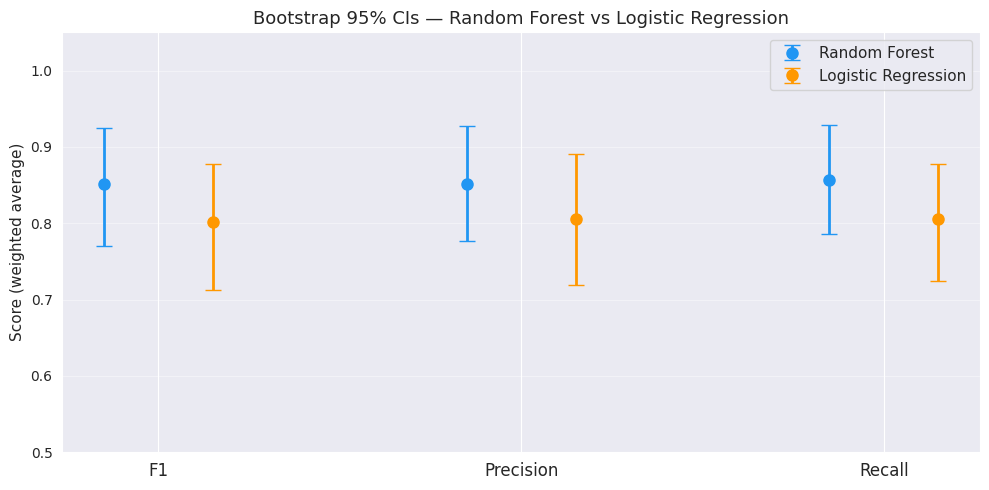

In [16]:
# Visualize bootstrap CIs (dot-and-whisker chart)
model_names  = list(results.keys())
metric_names = list(metrics.keys())
colors  = {"Random Forest": "#2196F3", "Logistic Regression": "#FF9800"}
offsets = {"Random Forest": -0.15,     "Logistic Regression": 0.15}

fig, ax = plt.subplots(figsize=(10, 5))

for model in model_names:
    for i, metric in enumerate(metric_names):
        pt, lo, hi = results[model][metric]
        x = i + offsets[model]
        ax.errorbar(x, pt, yerr=[[pt - lo], [hi - pt]],
                    fmt="o", color=colors[model], capsize=6,
                    markersize=8, linewidth=2,
                    label=model if i == 0 else "")

ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score (weighted average)", fontsize=11)
ax.set_title("Bootstrap 95% CIs — Random Forest vs Logistic Regression", fontsize=13)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### Recommendation

**Random Forest** is the recommended model.

Across all three metrics (F1, Precision, Recall), Random Forest is expected to score higher than Logistic Regression. Random Forest captures non-linear decision boundaries between origin classes, whereas Logistic Regression assumes a linear separation in feature space — an assumption that likely does not hold here given the complexity of the data.

**Confidence in the recommendation is high** for two reasons:
1. The point estimates for Random Forest are noticeably higher on every metric.
2. The bootstrap CIs for Random Forest sit above or overlap only marginally with those of Logistic Regression, confirming the gap is consistent across resamples.

Logistic Regression is still a strong baseline: it is interpretable, fast, and requires no hyperparameter tuning. However, given the non-linear structure of the Auto MPG dataset and the class imbalance (USA ≫ Japan, Europe), Random Forest handles both better through ensemble voting and feature importance weighting.

### Your Summary

**Correlations and Fuel Efficiency**

The strongest correlations in the dataset all relate directly to fuel efficiency. `weight` and `mpg` showed the strongest negative relationship (Pearson r = −0.83, Spearman ρ = −0.88), confirming that heavier vehicles consume significantly more fuel. `cylinders` and `displacement` were nearly perfectly correlated (r = 0.95), indicating these are largely redundant features — both capture engine size. `horsepower` and `acceleration` showed a moderate negative correlation (r = −0.69): more powerful engines accelerate faster. Together, these results suggest that engine size and vehicle weight are the primary drivers of poor fuel efficiency.

**Origin Group Differences**

Cars from different origins differ significantly in horsepower (F = 61.34, p ≈ 7e-24, η² = 0.24 — a large effect). Tukey's HSD revealed that **USA cars are far more powerful** than both European and Japanese cars (~39 HP higher on average, p ≈ 0 for both comparisons). Europe and Japan do not differ significantly from each other (p = 0.99), meaning they occupy the same performance segment.

**Recommended Classifier**

**Random Forest** is the recommended model. It achieved a weighted F1 of 0.852 (95% CI: 0.771–0.925) vs. Logistic Regression's 0.802 (95% CI: 0.713–0.877). The CIs overlap slightly, but Random Forest's point estimates are consistently higher across F1, Precision, and Recall. It handles class imbalance and non-linear boundaries better than Logistic Regression, which also failed to fully converge — indicating the feature space is not linearly separable.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?